In [3]:
import pandas as pd
df = pd.read_csv("134.1-playStore.csv")
df.duplicated("App")

0        False
1        False
2        False
3        False
4        False
         ...  
10836    False
10837    False
10838    False
10839    False
10840    False
Length: 10841, dtype: bool

In [4]:
df[df.duplicated("App")].shape

(1181, 13)

In [5]:
df_copy = pd.read_csv("134.2-google_cleaned.csv")
## Observation - The dataset has duplicate records

if "Unnamed: 0" in df_copy.columns:
    df_copy.drop("Unnamed: 0", axis=1, inplace=True)
df_copy.shape

(10840, 16)

In [6]:
## Explore data 
numeric_features = [
    feature for feature in df_copy.columns
    if df_copy[feature].dtype != "O"
]
categorical_features = [
    feature for feature in df_copy.columns
    if df_copy[feature].dtype == "O"
]

In [7]:
## Print columns
print("We have {} numerical features".format(len(numeric_features)))
print("We have {} categorical features".format(len(categorical_features)))

We have 16 numerical features
We have 0 categorical features


In [8]:
## Proportion of count on categorical columns
for col in categorical_features:
    print(df[col].value_count(normalize=True)*100)
    print("---------------------------------------")

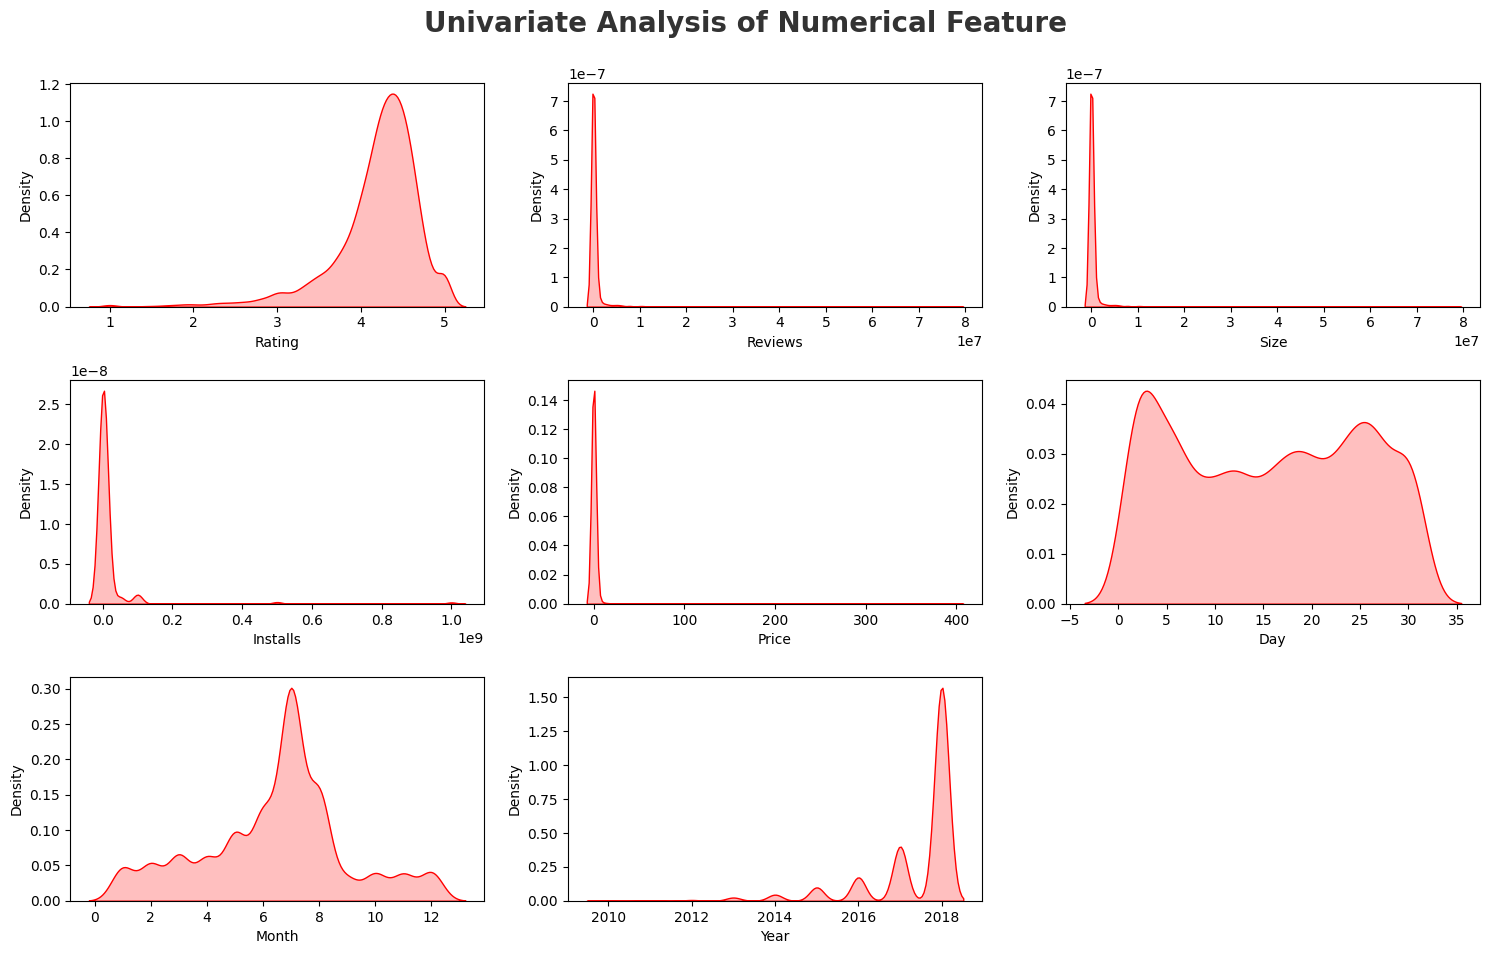

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Remove extra column
if "Unnamed: 0" in df_copy.columns:
    df_copy.drop("Unnamed: 0", axis=1, inplace=True)

# Select only numeric columns
numeric_features = df_copy.select_dtypes(include='number').columns

## Proportion of count data on numerical columns

plt.figure(figsize=(15,15))

plt.suptitle(
    "Univariate Analysis of Numerical Feature",
    fontsize=20,
    fontweight='bold',
    alpha=0.8,
    y=1.0
)

for i in range(0, len(numeric_features)):
    
    plt.subplot(5,3,i+1)

    sns.kdeplot(
        x=df_copy[numeric_features[i]],
        fill=True,
        color='r'
    )

    plt.xlabel(numeric_features[i])

plt.tight_layout()

plt.show()

Which is the most popular app category ?

In [10]:
df_copy.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,159.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,967.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018


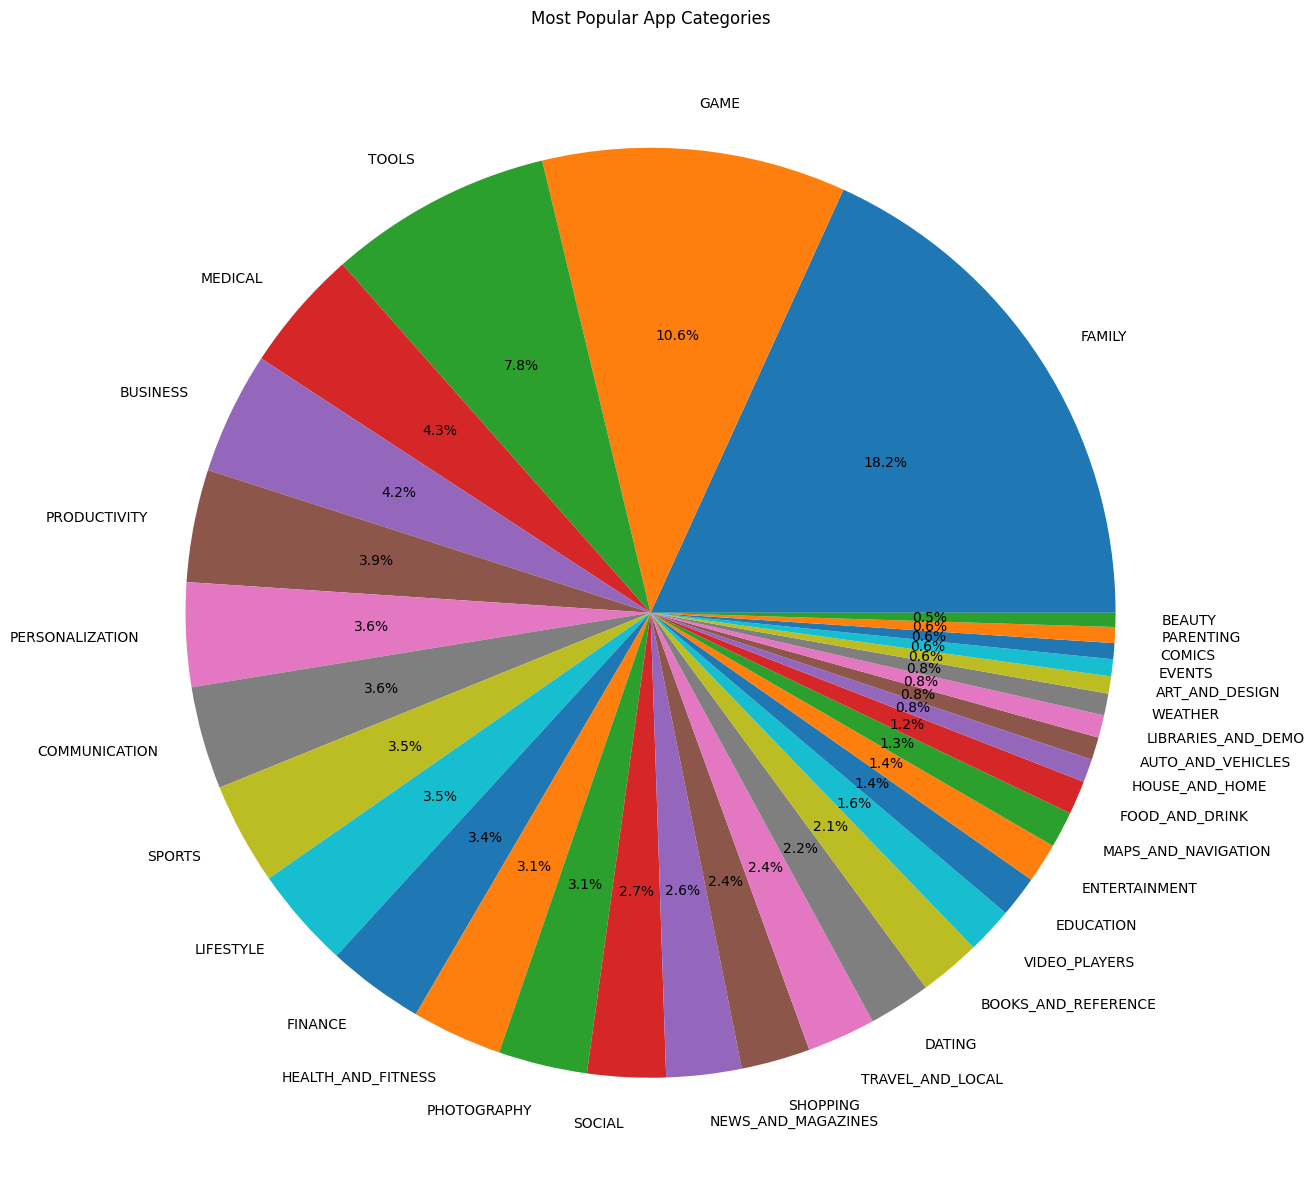

In [11]:
df_copy['Category'].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(15,16)
)

plt.title("Most Popular App Categories")

plt.ylabel("")

plt.show()

## Top 10 Categories

In [12]:
category = df_copy['Category'].value_counts().reset_index()

category.columns = ['Category', 'Count']

category

,Category,Count
0,FAMILY,1972
1,GAME,1144
2,TOOLS,843
3,MEDICAL,463
4,BUSINESS,460
5,PRODUCTIVITY,424
6,PERSONALIZATION,392
7,COMMUNICATION,387
8,SPORTS,384
9,LIFESTYLE,382


In [13]:
plt.figure(figsize= (15,6))

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

C:\Users\gp298\AppData\Local\Temp\ipykernel_11040\2128136068.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


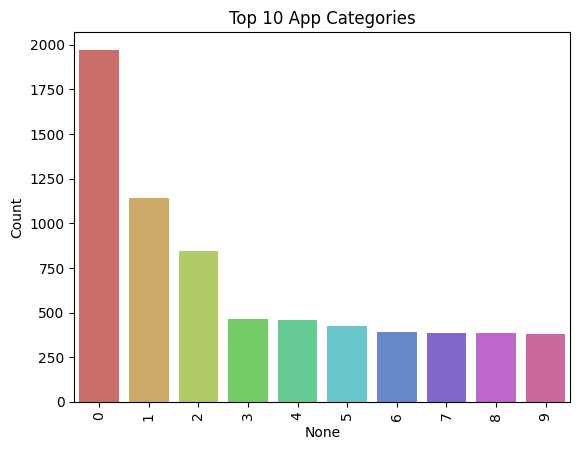

In [17]:
sns.barplot(
    x=category.index[:10],
    y='Count',
    data=category[:10],
    palette='hls'
)
plt.title("Top 10 App Categories")
plt.xticks(rotation = 90)
plt.show()